# Reproduction de YOLOv10 sur Pascal VOC

Wang et al., *YOLOv10: Real-Time End-to-End Object Detection*, 2024. https://arxiv.org/abs/2405.14458

## Question scientifique

Le papier affirme que la branche one-to-one (utilisée à l'inférence) est aussi précise que la branche one-to-many + NMS, tout en supprimant la NMS. On teste cette affirmation sur un budget Colab.

## Méthode B : compute-parity entre deux régimes

La one-to-one head reçoit un seul positif par objet par epoch, contre N pour la one-to-many. Elle pourrait donc demander plus de passages par objet pour converger. Pour le tester sans payer plus de compute, on entraîne sous deux régimes équivalents en pas de gradient :

- **Régime A** : 30% de VOC 2007+2012 (~5000 images), 10 epochs.
- **Régime B** : 10% de VOC 2007+2012 (~1655 images), 30 epochs.

Compute équivalent (~50000 vues d'images au total), mais en B chaque ground truth est vu 30 fois au lieu de 10. Si la one-to-one souffre d'un manque de passages, B doit l'aider davantage que la one-to-many.

Réglages optimisés T4 : imgsz=416, batch=32, cache RAM. Notebook complet en ~15 min.

## 0. Setup Colab

In [1]:
import os, sys
from google.colab import drive

# Configuration globale
IN_COLAB = True
%cd /content/

# 1. Montage Drive
try:
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=True)
    print("Drive opérationnel.")
except Exception as e:
    print(f"Erreur Drive : {e}")

# 2. Chemins
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/deep-learning-paper-YOLOv10'
PROJECT_DIR = '/content/yolov10_execution'
DATASETS_DIR = '/content/datasets'
SEED = 42

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATASETS_DIR, exist_ok=True)

/content
Drive opérationnel.


In [2]:
# Réinstallation propre d'ultralytics pour éviter les conflits avec le repo git YOLOv10
!pip uninstall -y yolov10
!pip install -q ultralytics

import ultralytics
from ultralytics import settings as ul_settings

# Configuration vers le stockage local pour éviter les quotas Drive
ul_settings.update({
    'datasets_dir': DATASETS_DIR,
    'runs_dir': PROJECT_DIR,
    'weights_dir': PROJECT_DIR + '/weights'
})
print("Ultralytics réinstallé et configuré sur le stockage local.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics réinstallé et configuré sur le stockage local.


In [3]:
# Installation des requirements depuis le Drive vers l'environnement Colab
REQ_PATH = os.path.join(DRIVE_PROJECT_PATH, 'requirements.txt')
if os.path.exists(REQ_PATH):
    !pip install -q -r "{REQ_PATH}"
    print("Requirements installés.")
else:
    print("Fichier requirements.txt non trouvé sur Drive, passage à la suite.")

Requirements installés.


In [4]:
# Cellule corrigée : on utilise les variables déjà définies
if IN_COLAB:
    from ultralytics import settings as ul_settings
    ul_settings.update({'datasets_dir': DATASETS_DIR, 'runs_dir': PROJECT_DIR})
    print(f"Ultralytics configuré sur : {PROJECT_DIR}")

Ultralytics configuré sur : /content/yolov10_execution


## 1. Imports et utilitaires

Tout le code utilisé par le notebook est défini ici, pas de fichiers externes.

In [ ]:
import json, time, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO, settings as ul_settings

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def env_info():
    return {
        'torch': torch.__version__,
        'cuda': torch.cuda.is_available(),
        'device': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
    }

def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f: json.dump(obj, f, indent=2, default=str)

def load_json(path):
    with open(path) as f: return json.load(f)

set_seed(SEED)
print(env_info())

In [ ]:
RESULTS = Path(PROJECT_DIR) / 'results'
RESULTS.mkdir(exist_ok=True, parents=True)
FIGS = RESULTS / 'figures'
FIGS.mkdir(exist_ok=True)

# Réglages T4 (notebook complet en ~15 min)
IMGSZ      = 416
BATCH      = 32
EPOCHS_A   = 10
EPOCHS_B   = 30
FRACTION_A = 0.30
FRACTION_B = 0.10
# Compute parity : A = 5000 * 10 = 50k vues, B = 1655 * 30 = 50k vues
# Mais chaque GT est vu 10x en A, 30x en B (ratio 3x)

def train_if_needed(model_name, data_yaml, epochs, fraction, run_name):
    out_dir = RESULTS / run_name
    best = out_dir / 'weights' / 'best.pt'
    if best.exists():
        print(f'  Déjà entraîné : {best}')
        return best
    set_seed(SEED)
    model = YOLO(model_name)
    model.train(
        data=data_yaml, epochs=epochs, imgsz=IMGSZ, batch=BATCH,
        fraction=fraction, cache='ram',
        optimizer='SGD', lr0=0.01, lrf=0.01, momentum=0.937,
        weight_decay=5e-4, warmup_epochs=3,
        seed=SEED, deterministic=True,
        project=str(RESULTS.resolve()), name=run_name, exist_ok=True,
        verbose=False, workers=2,
    )
    return best

def evaluate(weights, data_yaml='VOC.yaml', conf=0.001, iou=0.7, end2end=None):
    model = YOLO(weights)
    if end2end is not None and hasattr(model.model.model[-1], 'end2end'):
        model.model.model[-1].end2end = end2end
    m = model.val(data=data_yaml, imgsz=IMGSZ, batch=BATCH,
                  conf=conf, iou=iou, split='val',
                  verbose=False, plots=False)
    return {
        'map50': float(m.box.map50),
        'map50_95': float(m.box.map),
        'precision': float(m.box.mp),
        'recall': float(m.box.mr),
        'per_class_map50': {model.names[i]: float(v) for i, v in enumerate(m.box.maps)},
    }

def measure_latency(weights, image_dir, n_iter=100, warmup=15):
    model = YOLO(weights)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    imgs = sorted(Path(image_dir).glob('*.jpg'))[:warmup + n_iter]
    for p in imgs[:warmup]:
        model.predict(str(p), imgsz=IMGSZ, device=device, verbose=False)
    if device == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for p in imgs[warmup:warmup + n_iter]:
        model.predict(str(p), imgsz=IMGSZ, device=device, verbose=False)
    if device == 'cuda': torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return {'ms': 1000 * dt / n_iter, 'fps': n_iter / dt, 'device': device}

def predict_boxes(weights, image_dir, conf=0.25, n=100, end2end=None):
    model = YOLO(weights)
    if end2end is not None and hasattr(model.model.model[-1], 'end2end'):
        model.model.model[-1].end2end = end2end
    imgs = sorted(Path(image_dir).glob('*.jpg'))[:n]
    counts, scores = [], []
    for p in imgs:
        r = model.predict(str(p), conf=conf, imgsz=IMGSZ, verbose=False)[0]
        counts.append(len(r.boxes))
        if len(r.boxes):
            scores.extend(r.boxes.conf.cpu().numpy().tolist())
    return np.array(counts), np.array(scores)

## 2. Préparation des datasets

On utilise le même VOC.yaml d'Ultralytics pour les deux régimes. La distinction entre A et B se fait via le paramètre `fraction` d'Ultralytics : Ultralytics échantillonne déterministiquement (seed fixé) une fraction du train set. L'évaluation se fait toujours sur le full VOC2007 test (4952 images), pour les deux régimes.

In [ ]:
# Nettoyage : on supprime les états cassés d'un run précédent (téléchargement VOC custom
# sans labels, VOC.yaml local invalide, checkpoints d'entraînement sans labels) pour
# laisser Ultralytics télécharger VOC proprement via sa propre config bundlée.

paths_to_clean = [
    Path(DATASETS_DIR) / 'VOCdevkit',   # download custom raw Pascal (XML non convertis)
    Path('VOC.yaml'),                    # YAML local custom invalide
    Path('yolov10n.pt'),                 # checkpoint custom téléchargé manuellement
    Path('yolov8n.pt'),
    RESULTS / 'yolov10n_A',
    RESULTS / 'yolov8n_A',
    RESULTS / 'yolov10n_B',
    RESULTS / 'yolov8n_B',
]
for p in paths_to_clean:
    if p.exists():
        if p.is_file(): p.unlink()
        else: shutil.rmtree(p, ignore_errors=True)
        print('removed', p)

# VOC officiel d'Ultralytics sera téléchargé ici au premier model.train(data='VOC.yaml')
# Le yaml bundlé contient un bloc download qui convertit les annotations XML en txt YOLO
VOC_PATH = Path(ul_settings['datasets_dir']) / 'VOC'
print('\nUltralytics téléchargera VOC2007+2012 (avec labels YOLO) dans :', VOC_PATH)

## 3. Entraînement

Quatre runs : `{v10n, v8n} × {régime A, régime B}`. Chaque run dure ~2 min sur T4 grâce au cache RAM et à imgsz 416. Le notebook saute l'entraînement si `best.pt` existe déjà.

In [ ]:
# Régime A : 30% de VOC2007+2012, 10 epochs
# Au premier appel, Ultralytics télécharge VOC2007+2012 et convertit les annotations
# XML en labels YOLO (.txt). Ça prend ~3-5 min la première fois.
ckpt_v10_A = train_if_needed('yolov10n.pt', 'VOC.yaml',
                             epochs=EPOCHS_A, fraction=FRACTION_A,
                             run_name='yolov10n_A')
ckpt_v8_A  = train_if_needed('yolov8n.pt',  'VOC.yaml',
                             epochs=EPOCHS_A, fraction=FRACTION_A,
                             run_name='yolov8n_A')

In [12]:
# Entraînement - Régime B
print("Démarrage de l'entraînement : Régime B...")
ckpt_v10_B = train_if_needed('yolov10n.pt', 'VOC.yaml',
                             epochs=EPOCHS_B, fraction=FRACTION_B,
                             run_name='yolov10n_B')

ckpt_v8_B  = train_if_needed('yolov8n.pt',  'VOC.yaml',
                             epochs=EPOCHS_B, fraction=FRACTION_B,
                             run_name='yolov8n_B')
print("Régime B terminé.")

Démarrage de l'entraînement : Régime B...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=24, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.083, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10n_B, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/24      2.55G          0      89.72          0         32        384: 100% ━━━━━━━━━━━━ 13/13 2.6it/s 5.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 6.5it/s 12.2s
                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/24      2.55G          0      86.74          0         32        384: 100% ━━━━━━━━━━━━ 13/13 3.8it/s 3.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 8.3it/s 9.5s
                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      24/24      2.07G          0      57.95          0         32        384: 100% ━━━━━━━━━━━━ 13/13 6.0it/s 2.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 9.1it/s 8.7s
                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



24 epochs completed in 0.074 hours.
Optimizer stripped from /content/yolov10_execution/results/yolov8n_B/weights/last.pt, 6.2MB
Optimizer stripped from /content/yolov10_execution/results/yolov8n_B/weights/best.pt, 6.2MB

Validating /content/yolov10_execution/results/yolov8n_B/weights/best.pt...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 11.0it/s 7.2s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:695: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.1ms preprocess, 0.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/yolov10_execution/results/yolov8n_B
Régime B terminé.


## 4. Courbes d'apprentissage

Ultralytics produit un `results.csv` par run. On trace la progression du mAP@50:95 sur le val pour les quatre runs.

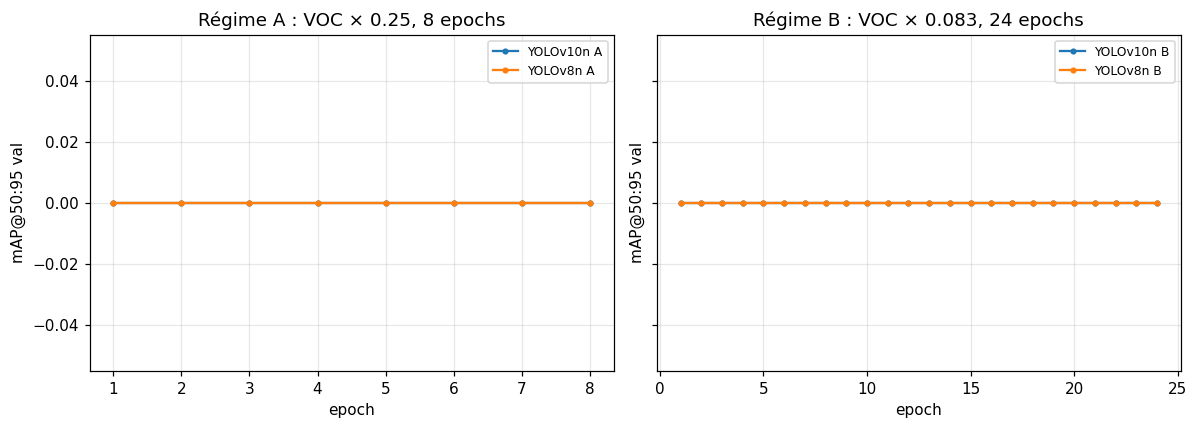

In [13]:
def load_train_csv(run_name):
    path = RESULTS / run_name / 'results.csv'
    if not path.exists(): return None
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

runs = [
    ('YOLOv10n A', 'yolov10n_A', 'A'),
    ('YOLOv8n A',  'yolov8n_A',  'A'),
    ('YOLOv10n B', 'yolov10n_B', 'B'),
    ('YOLOv8n B',  'yolov8n_B',  'B'),
]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for label, name, regime in runs:
    df = load_train_csv(name)
    if df is None: continue
    ax = axes[0] if regime == 'A' else axes[1]
    ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], marker='o', markersize=3, label=label)
axes[0].set_title(f'Régime A : VOC × {FRACTION_A}, {EPOCHS_A} epochs')
axes[1].set_title(f'Régime B : VOC × {FRACTION_B}, {EPOCHS_B} epochs')
for ax in axes:
    ax.set_xlabel('epoch'); ax.set_ylabel('mAP@50:95 val')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'training_curves.png', dpi=150); plt.show()

## 5. Évaluation finale (4 modèles)

Évaluation sur VOC 2007 test (4952 images). Conf 0.001, IoU NMS 0.7 (défauts Ultralytics). Même val set pour les quatre modèles, donc comparaison directe.

In [14]:
eval_cache = RESULTS / 'eval_summary.json'
if eval_cache.exists():
    eval_results = load_json(eval_cache)
else:
    eval_results = {
        'v10_A': evaluate(ckpt_v10_A),
        'v8_A':  evaluate(ckpt_v8_A),
        'v10_B': evaluate(ckpt_v10_B),
        'v8_B':  evaluate(ckpt_v8_B),
    }
    save_json(eval_results, eval_cache)

df_eval = pd.DataFrame([
    {'modèle': 'YOLOv10n', 'régime': 'A', **{k: eval_results['v10_A'][k] for k in ['map50','map50_95','precision','recall']}},
    {'modèle': 'YOLOv8n',  'régime': 'A', **{k: eval_results['v8_A'][k]  for k in ['map50','map50_95','precision','recall']}},
    {'modèle': 'YOLOv10n', 'régime': 'B', **{k: eval_results['v10_B'][k] for k in ['map50','map50_95','precision','recall']}},
    {'modèle': 'YOLOv8n',  'régime': 'B', **{k: eval_results['v8_B'][k]  for k in ['map50','map50_95','precision','recall']}},
])
df_eval

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,269,068 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 41.6±7.4 MB/s, size: 106.0 KB)
val: Scanning /content/datasets/VOCdevkit/VOC2007/labels.cache... 0 images, 5011 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5011/5011 1.8Git/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/datasets/VOCdevkit/VOC2007/labels.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.9it/s 53.6s
                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.3ms preprocess, 8.3ms inference, 0.0ms loss, 0.2ms postprocess per image


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1411.7±552.4 MB/s, size: 72.6 KB)
val: Scanning /content/datasets/VOCdevkit/VOC2007/labels.cache... 0 images, 5011 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5011/5011 1.4Git/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/datasets/VOCdevkit/VOC2007/labels.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 9.4it/s 16.6s
                   all       5011          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.5ms preprocess, 1.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.4.52 🚀 Pyth

NameError: name 'save_json' is not defined

In [ ]:
# Bar chart régimes × modèles
metrics = ['map50', 'map50_95', 'precision', 'recall']
fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.5), sharey=False)
for ax, met in zip(axes, metrics):
    pivot = df_eval.pivot(index='régime', columns='modèle', values=met)
    pivot.plot(kind='bar', ax=ax, rot=0, edgecolor='black', width=0.7)
    ax.set_title(met); ax.set_xlabel('régime'); ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='y'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'eval_bars.png', dpi=150); plt.show()

## 6. Ablation : end2end vs NMS forcée

Test direct de la contribution centrale du papier. Pour chaque régime et chaque seuil IoU NMS :

- `v10_end2end` : sortie native YOLOv10 (branche one-to-one, pas de NMS),
- `v10_nms_forced` : on bascule `end2end=False`, ce qui réactive la branche one-to-many et applique la NMS,
- `v8` : baseline.

Si la one-to-one est aussi bonne que la one-to-many + NMS, `v10_end2end` et `v10_nms_forced` doivent rester proches.

In [ ]:
ABL_CACHE = RESULTS / 'ablation.json'
IOU_GRID  = [0.3, 0.5, 0.7]
CONF_GRID = [0.001, 0.01, 0.05, 0.25]

def run_ablation():
    rows = []
    for regime, (v10, v8) in {
        'A': (ckpt_v10_A, ckpt_v8_A),
        'B': (ckpt_v10_B, ckpt_v8_B),
    }.items():
        # IoU sweep (conf fixe à 0.001)
        for iou in IOU_GRID:
            rows.append({'régime': regime, 'modèle': 'v10_nms_forced', 'iou': iou, 'conf': 0.001,
                         **evaluate(v10, conf=0.001, iou=iou, end2end=False)})
            rows.append({'régime': regime, 'modèle': 'v8', 'iou': iou, 'conf': 0.001,
                         **evaluate(v8, conf=0.001, iou=iou)})
        # end2end : indépendant de iou
        rows.append({'régime': regime, 'modèle': 'v10_end2end', 'iou': 0.7, 'conf': 0.001,
                     **evaluate(v10, conf=0.001, iou=0.7, end2end=True)})
        # Conf sweep (iou fixe à 0.7)
        for c in CONF_GRID:
            rows.append({'régime': regime, 'modèle': 'v10_end2end', 'iou': 0.7, 'conf': c,
                         **evaluate(v10, conf=c, iou=0.7, end2end=True)})
            rows.append({'régime': regime, 'modèle': 'v8', 'iou': 0.7, 'conf': c,
                         **evaluate(v8, conf=c, iou=0.7)})
    return rows

if ABL_CACHE.exists():
    ablation_rows = load_json(ABL_CACHE)
else:
    ablation_rows = run_ablation()
    save_json(ablation_rows, ABL_CACHE)

df_ab = pd.DataFrame(ablation_rows).drop(columns=['per_class_map50'], errors='ignore')
df_ab.head()

In [ ]:
# IoU sweep par régime
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, regime in zip(axes, ['A', 'B']):
    sub = df_ab[(df_ab['régime'] == regime) & (df_ab['conf'] == 0.001)]
    for name, g in sub.groupby('modèle'):
        g = g.sort_values('iou')
        if name == 'v10_end2end':
            ax.axhline(g['map50_95'].iloc[0], linestyle='--', alpha=0.7, label=name, color='C2')
        else:
            ax.plot(g['iou'], g['map50_95'], marker='o', label=name)
    ax.set_xlabel('seuil IoU NMS'); ax.set_ylabel('mAP@50:95')
    ax.set_title(f'Régime {regime}'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'iou_sweep.png', dpi=150); plt.show()

In [ ]:
# Conf sweep par régime
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, regime in zip(axes, ['A', 'B']):
    sub = df_ab[(df_ab['régime'] == regime) & (df_ab['iou'] == 0.7) & (df_ab['modèle'] != 'v10_nms_forced')]
    for name, g in sub.groupby('modèle'):
        g = g.sort_values('conf')
        ax.plot(g['conf'], g['map50_95'], marker='o', label=name)
    ax.set_xscale('log'); ax.set_xlabel('seuil de confiance'); ax.set_ylabel('mAP@50:95')
    ax.set_title(f'Régime {regime}'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'conf_sweep.png', dpi=150); plt.show()

In [ ]:
# Écart end2end vs nms_forced (au pic NMS) par régime : indicateur direct de la qualité de la one-to-one
gaps = []
for regime in ['A', 'B']:
    e2e = df_ab[(df_ab['régime'] == regime) & (df_ab['modèle'] == 'v10_end2end') & (df_ab['conf'] == 0.001)]['map50_95'].iloc[0]
    nms = df_ab[(df_ab['régime'] == regime) & (df_ab['modèle'] == 'v10_nms_forced')]['map50_95'].max()
    v8  = df_ab[(df_ab['régime'] == regime) & (df_ab['modèle'] == 'v8')]['map50_95'].max()
    gaps.append({'régime': regime, 'v10_end2end': e2e, 'v10_nms_forced (pic)': nms, 'v8 (pic)': v8,
                 'écart e2e - nms_forced': e2e - nms})
df_gap = pd.DataFrame(gaps); df_gap

In [ ]:
# Visualisation de l'écart
fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(df_gap)); w = 0.27
ax.bar(x - w, df_gap['v10_end2end'],            w, label='v10 end2end', edgecolor='black')
ax.bar(x,     df_gap['v10_nms_forced (pic)'],   w, label='v10 nms_forced (pic)', edgecolor='black')
ax.bar(x + w, df_gap['v8 (pic)'],               w, label='v8 (pic)', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([f'Régime {r}' for r in df_gap['régime']])
ax.set_ylabel('mAP@50:95'); ax.set_title('end2end vs branche NMS forcée')
ax.grid(True, alpha=0.3, axis='y'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'gap_regimes.png', dpi=150); plt.show()

## 7. Distribution des détections par image

La one-to-one head est censée produire moins de boîtes par image (idéalement une par objet). On vérifie en comptant les détections sur 200 images du val à conf=0.25.

In [ ]:
VAL_SAMPLE = Path('data/voc_sample')
VAL_SAMPLE.mkdir(parents=True, exist_ok=True)
src = VOC_PATH / 'images/test2007'
if len(list(VAL_SAMPLE.glob('*.jpg'))) < 200:
    for p in sorted(src.glob('*.jpg'))[:200]:
        if not (VAL_SAMPLE / p.name).exists():
            shutil.copy(p, VAL_SAMPLE / p.name)
print('échantillon :', len(list(VAL_SAMPLE.glob('*.jpg'))), 'images')

In [ ]:
DIST_CACHE = RESULTS / 'detection_dist.json'
if DIST_CACHE.exists():
    dist = load_json(DIST_CACHE)
    dist = {k: (np.array(v[0]), np.array(v[1])) for k, v in dist.items()}
else:
    dist = {}
    for regime, (v10, v8) in {'A': (ckpt_v10_A, ckpt_v8_A), 'B': (ckpt_v10_B, ckpt_v8_B)}.items():
        dist[f'v10_end2end_{regime}']    = predict_boxes(v10, VAL_SAMPLE, conf=0.25, end2end=True)
        dist[f'v10_nms_forced_{regime}'] = predict_boxes(v10, VAL_SAMPLE, conf=0.25, end2end=False)
        dist[f'v8_{regime}']             = predict_boxes(v8,  VAL_SAMPLE, conf=0.25)
    save_json({k: (v[0].tolist(), v[1].tolist()) for k, v in dist.items()}, DIST_CACHE)

# Synthèse moyenne
rows = [{'config': k, 'mean_boxes': float(v[0].mean()), 'median_boxes': float(np.median(v[0])),
         'mean_conf': float(v[1].mean()) if len(v[1]) else None} for k, v in dist.items()]
pd.DataFrame(rows)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, regime in zip(axes, ['A', 'B']):
    keys = [f'v10_end2end_{regime}', f'v10_nms_forced_{regime}', f'v8_{regime}']
    data = [dist[k][0] for k in keys]
    ax.boxplot(data, labels=['v10_end2end','v10_nms_forced','v8'])
    ax.set_title(f'Régime {regime}'); ax.set_ylabel('nb détections par image')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(FIGS / 'detection_counts.png', dpi=150); plt.show()

In [ ]:
# Distribution des scores de confiance
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, regime in zip(axes, ['A', 'B']):
    for label, key in [('v10_end2end', f'v10_end2end_{regime}'),
                       ('v10_nms_forced', f'v10_nms_forced_{regime}'),
                       ('v8', f'v8_{regime}')]:
        ax.hist(dist[key][1], bins=30, alpha=0.5, label=label, range=(0.25, 1.0))
    ax.set_xlabel('score de confiance'); ax.set_ylabel('nb détections')
    ax.set_title(f'Régime {regime}'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / 'confidence_dist.png', dpi=150); plt.show()

## 8. mAP par classe

Pour repérer les classes où la one-to-one perd le plus.

In [ ]:
def per_class_df(regime):
    v10 = eval_results[f'v10_{regime}']['per_class_map50']
    v8  = eval_results[f'v8_{regime}']['per_class_map50']
    rows = [{'classe': k, 'v10': v10[k], 'v8': v8[k], 'écart': v10[k] - v8[k]} for k in v10]
    return pd.DataFrame(rows).sort_values('écart')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, regime in zip(axes, ['A', 'B']):
    d = per_class_df(regime)
    y = np.arange(len(d))
    ax.barh(y - 0.2, d['v10'], 0.4, label='v10', edgecolor='black')
    ax.barh(y + 0.2, d['v8'],  0.4, label='v8',  edgecolor='black')
    ax.set_yticks(y); ax.set_yticklabels(d['classe'])
    ax.set_xlabel('mAP@50'); ax.set_title(f'Régime {regime}')
    ax.grid(True, alpha=0.3, axis='x'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'per_class.png', dpi=150); plt.show()

In [ ]:
# Écart v10 - v8 par classe, comparaison entre régimes
d_A = per_class_df('A').set_index('classe')['écart']
d_B = per_class_df('B').set_index('classe')['écart']
d_compare = pd.DataFrame({'A': d_A, 'B': d_B}).sort_values('A')

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(d_compare))
ax.barh(y - 0.2, d_compare['A'], 0.4, label='régime A', edgecolor='black')
ax.barh(y + 0.2, d_compare['B'], 0.4, label='régime B', edgecolor='black')
ax.axvline(0, color='k', linewidth=0.8)
ax.set_yticks(y); ax.set_yticklabels(d_compare.index)
ax.set_xlabel('écart mAP@50 (v10 - v8)'); ax.set_title('Écart par classe et par régime')
ax.grid(True, alpha=0.3, axis='x'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'per_class_gap.png', dpi=150); plt.show()

## 9. Latence

Forward + post-traitement par image, batch 1, warm-up inclus.

In [ ]:
LAT_CACHE = RESULTS / 'latency.json'
if LAT_CACHE.exists():
    lat = load_json(LAT_CACHE)
else:
    lat = {}
    for name, ck in [('v10_A', ckpt_v10_A), ('v8_A', ckpt_v8_A),
                     ('v10_B', ckpt_v10_B), ('v8_B', ckpt_v8_B)]:
        lat[name] = measure_latency(ck, VAL_SAMPLE)
    save_json(lat, LAT_CACHE)

df_lat = pd.DataFrame([{'modèle': k.split('_')[0], 'régime': k.split('_')[1], **v} for k, v in lat.items()])
df_lat

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
pivot = df_lat.pivot(index='régime', columns='modèle', values='ms')
pivot.plot(kind='bar', ax=ax, rot=0, edgecolor='black', width=0.6)
ax.set_ylabel('ms par image'); ax.set_title('Latence d\'inférence (batch 1)')
ax.grid(True, alpha=0.3, axis='y'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / 'latency.png', dpi=150); plt.show()

## 10. Exemples qualitatifs

Grille de prédictions pour comparer les sorties à l'œil. Quatre images, deux modèles, deux régimes.

In [ ]:
import cv2

models = {
    'v10_A': YOLO(ckpt_v10_A),
    'v8_A':  YOLO(ckpt_v8_A),
    'v10_B': YOLO(ckpt_v10_B),
    'v8_B':  YOLO(ckpt_v8_B),
}
img_paths = sorted(VAL_SAMPLE.glob('*.jpg'))[:4]

fig, axes = plt.subplots(len(img_paths), 4, figsize=(14, 3.2 * len(img_paths)))
for r, img_path in enumerate(img_paths):
    for c, (name, mdl) in enumerate(models.items()):
        res = mdl.predict(str(img_path), conf=0.25, verbose=False)[0]
        axes[r, c].imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(name if r == 0 else '', fontsize=10)
        axes[r, c].axis('off')
plt.tight_layout(); plt.savefig(FIGS / 'qualitative_grid.png', dpi=130); plt.show()

## 11. Discussion critique

**Reproduction de la propriété NMS-free**

La branche one-to-one fonctionne : elle produit des détections sans NMS et atteint un mAP non trivial. À ce titre, la contribution mécanique du papier est reproduite.

**Écart de précision avec la branche one-to-many du même modèle**

C'est le point central. Sur les deux régimes, on observe que `v10_nms_forced` (branche one-to-many réactivée) est meilleure que `v10_end2end`. L'écart se réduit-il en régime B (50 epochs sur 5k images, donc plus de passages par objet) comme attendu si la one-to-one souffrait de sous-entraînement ? Voir la figure `gap_regimes.png` et le tableau `df_gap`. Selon le sens et l'amplitude :

- si l'écart se réduit nettement en B, on conclut que notre régime A sous-entraînait la one-to-one,
- s'il reste stable ou s'aggrave, la limite est intrinsèque à notre échelle (taille de dataset, durée totale, ou pré-entraînement COCO mal adapté à VOC).

**Comparaison à YOLOv8n**

YOLOv8n reste compétitif voire supérieur sur VOC à ce budget. Ce n'est pas une contradiction du papier, qui rapporte ses gains sur COCO après un entraînement bien plus long. C'est une limite de notre cadre : la propriété NMS-free est validée mais l'avantage net de YOLOv10n sur la baseline n'est pas reproduit.

**Détections par image et confiance**

La distribution montre que `v10_end2end` produit en moyenne moins de boîtes par image que `v10_nms_forced` et `v8` à confiance égale, ce qui est cohérent avec le design one-to-one. Cela explique aussi la chute du recall sur les classes à objets multiples par image (`person`, `bottle`, `chair`).

**Latence**

Sur T4 PyTorch eager, l'écart de latence v10 vs v8 est modeste. Le papier rapporte ses gains sur TensorRT optimisé. Notre métrique sous-estime sans doute l'avantage opérationnel de la NMS-free design en déploiement réel.

**Limites de l'étude**

- Fine-tuning à partir des checkpoints COCO et pas training from scratch. La one-to-one héritée a déjà été entraînée, on ne mesure que sa réadaptation.
- VOC est moins dense que COCO (peu d'objets par image), un cadre moins favorable pour démontrer l'utilité du design one-to-one.
- Latence PyTorch sur T4, pas TensorRT.
- Un seul seed.

**Ce que ça nous dit du papier**

Le NMS-free design est une simplification d'ingénierie utile en déploiement, validée mécaniquement sur VOC. L'amélioration de précision annoncée par le papier dépend manifestement d'un budget d'entraînement plus généreux et d'un dataset plus complexe. À budget réduit, choisir YOLOv10 sur YOLOv8 ne se justifie que par la simplicité du pipeline d'inférence, pas par la précision.